In [5]:
import torch
import torch.nn as nn
import numpy as np
import os
import kagglehub
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torchvision import datasets, transforms, models
from PIL import Image

# 1. Tải dataset và cấu hình thiết bị
path = kagglehub.dataset_download("hutinguynhunh/garbage-classification-v2")
print("Đường dẫn dataset:", path)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Sử dụng thiết bị: {device}')

# 2. Định nghĩa Dataset
class GarbageDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.img_dir = os.path.join(folder_path, 'images')
        self.transform = transform
        self.images = [f for f in os.listdir(self.img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        self.classes = sorted(list(set([f.split('0')[0].split('1')[0].split('2')[0].split('3')[0].split('4')[0].split('5')[0].split('6')[0].split('7')[0].split('8')[0].split('9')[0].replace('_jpg.rf.', '') for f in self.images])))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

    def __getitem__(self, ix):
        img_name = self.images[ix]
        label_str = next(cls for cls in self.classes if img_name.startswith(cls))
        label = self.class_to_idx[label_str]
        img_path = os.path.join(self.img_dir, img_name)
        img = Image.open(img_path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, torch.tensor(label)

    def __len__(self):
        return len(self.images)

# 3. Chuẩn bị DataLoader
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_set = GarbageDataset(os.path.join(path, 'train'), transform=train_transform)
val_set = GarbageDataset(os.path.join(path, 'valid'), transform=val_transform)
trn_dl = DataLoader(train_set, batch_size=32, shuffle=True)
val_dl = DataLoader(val_set, batch_size=32, shuffle=False)
num_classes = len(train_set.classes)

# 4. Định nghĩa mô hình
def get_model(num_classes):
    model = models.resnet18(weights='IMAGENET1K_V1')
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model = model.to(device)
    return model, nn.CrossEntropyLoss(), Adam(model.parameters(), lr=0.0001)

model, loss_fn, optimizer = get_model(num_classes)

def train_batch(x, y, model, opt, loss_fn):
    model.train()
    opt.zero_grad()
    prediction = model(x.to(device))
    batch_loss = loss_fn(prediction, y.to(device))
    batch_loss.backward()
    opt.step()
    return batch_loss.item()

@torch.no_grad()
def accuracy(x, y, model):
    model.eval()
    prediction = model(x.to(device))
    is_correct = (prediction.max(-1)[1] == y.to(device))
    return is_correct.cpu().numpy().tolist()

# 5. Vòng lặp huấn luyện
train_losses, val_accuracies = [], []
print(f"Bắt đầu huấn luyện với {num_classes} lớp: {train_set.classes}")

for epoch in range(5):
    epoch_losses = []
    for i, (x, y) in enumerate(trn_dl):
        loss = train_batch(x, y, model, optimizer, loss_fn)
        epoch_losses.append(loss)
        if i % 50 == 0: print(f"Batch {i} loss: {loss:.4f}")

    val_accs = []
    for x, y in val_dl:
        val_accs.extend(accuracy(x, y, model))

    avg_loss = np.mean(epoch_losses)
    avg_val_acc = np.mean(val_accs)
    train_losses.append(avg_loss)
    val_accuracies.append(avg_val_acc)
    print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Val Acc={avg_val_acc*100:.2f}%")

100%|██████████| 481M/481M [00:04<00:00, 108MB/s]

Extracting files...


Đường dẫn dataset: /root/.cache/kagglehub/datasets/hutinguynhunh/garbage-classification-v2/versions/1
Sử dụng thiết bị: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s]


Bắt đầu huấn luyện với 7 lớp: ['biodegradable', 'cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Batch 0 loss: 2.1944
Batch 50 loss: 0.6132
Batch 100 loss: 0.5513
Batch 150 loss: 0.5244
Batch 200 loss: 0.2645
Batch 250 loss: 0.4336
Batch 300 loss: 0.2059
Batch 350 loss: 0.3832
Batch 400 loss: 0.4705
Batch 450 loss: 0.1330
Batch 500 loss: 0.1870
Batch 550 loss: 0.0742
Epoch 1: Loss=0.3246, Val Acc=92.71%
Batch 0 loss: 0.0727
Batch 50 loss: 0.0505
Batch 100 loss: 0.0741
Batch 150 loss: 0.1889
Batch 200 loss: 0.0480
Batch 250 loss: 0.0855
Batch 300 loss: 0.1524
Batch 350 loss: 0.1408
Batch 400 loss: 0.1225
Batch 450 loss: 0.2225
Batch 500 loss: 0.0354
Batch 550 loss: 0.0309
Epoch 2: Loss=0.1236, Val Acc=91.81%
Batch 0 loss: 0.1376
Batch 50 loss: 0.1178
Batch 100 loss: 0.0490
Batch 150 loss: 0.0245
Batch 200 loss: 0.0427
Batch 250 loss: 0.0153
Batch 300 loss: 0.0696
Batch 350 loss: 0.1968
Batch 400 loss: 0.0144
Batch 450 loss: 0.0903
Batch 500 loss: 0.0149
Batch 550 loss: 0.0491

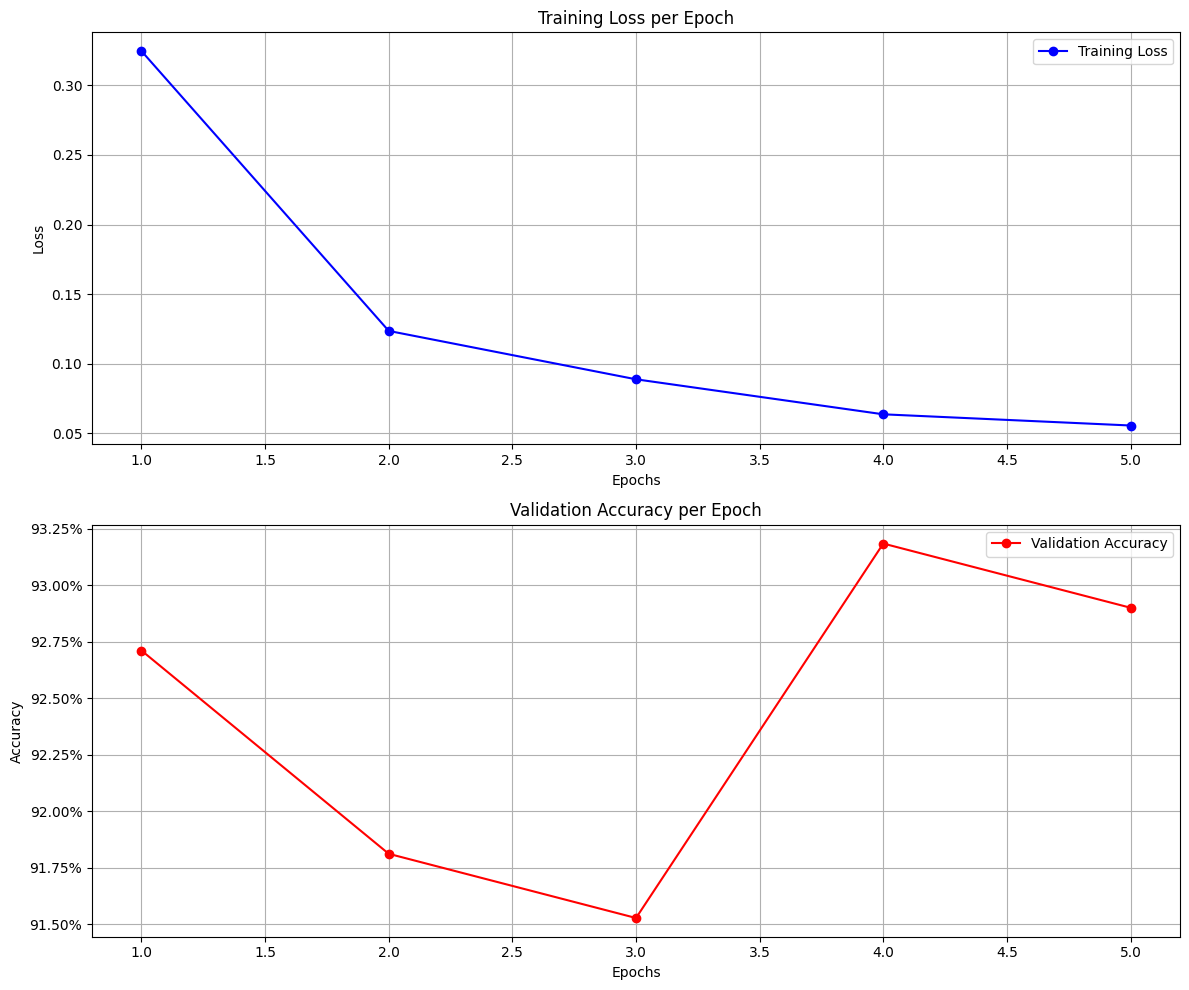

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Lấy số lượng epoch thực tế đã chạy từ biến train_losses
epochs_range = np.arange(len(train_losses)) + 1

plt.figure(figsize=(12, 10))

# 1. Biểu đồ Loss
plt.subplot(2, 1, 1)
plt.plot(epochs_range, train_losses, 'bo-', label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Biểu đồ Accuracy
plt.subplot(2, 1, 2)
plt.plot(epochs_range, val_accuracies, 'r-o', label='Validation Accuracy')
plt.title('Validation Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
# Định dạng trục y thành phần trăm
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()